# Dueling Double DQN with OpenSpiel 2048

This notebook trains a **Dueling Double DQN** agent on the OpenSpiel 2048 environment.

Compared with vanilla DQN, this combines two improvements:
- **Dueling DQN**: Decomposes Q-values into state value V(s) and action advantage A(s,a) for better learning.
- **Double DQN**: Uses the online network to select actions and the target network to evaluate them, reducing overestimation bias.

The rest of the training pipeline remains the same.

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pyspiel
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm

print("PyTorch version:", torch.__version__)
print("OpenSpiel version:", pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown")
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.5.1+cu121
OpenSpiel version: 1.6.12
CUDA available: True
Device: cuda


## 1. Load and inspect OpenSpiel 2048

OpenSpiel represents a game as a `Game` object and a playthrough position as a `State`. The 2048 game includes randomness, so we resolve chance nodes inside the environment wrapper.

In [2]:
game = pyspiel.load_game("2048")
state = game.new_initial_state()

game_type = game.get_type()
short_name = game_type.short_name if hasattr(game_type, "short_name") else "2048"

print("Registered game:", short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max chance outcomes:", game.max_chance_outcomes())
print("Max game length:", game.max_game_length())
print("Min / Max utility:", game.min_utility(), game.max_utility())
print()
print("Initial state is chance node:", state.is_chance_node())
print("Initial state string:")
print(state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max chance outcomes: 33
Max game length: 8192
Min / Max utility: 0.0 20480.0

Initial state is chance node: True
Initial state string:
    0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



## 2. Helper functions and environment wrapper

We reuse the repository helpers and the thin `OpenSpiel2048Env` wrapper.

In [ ]:
from app.helpers import extract_obs, legal_actions, parse_board_numbers, auto_resolve_chance_nodes, epsilon_by_step
from app.open_spiel_2048_env import OpenSpiel2048Env

test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
print("Observation shape after resolving initial chance:", extract_obs(test_state).shape)
print("Legal actions:", legal_actions(test_state))
print("Board (best effort):")
print(parse_board_numbers(test_state))
print()
print(test_state)

Observation shape after resolving initial chance: (16,)
Legal actions: [0, 1, 2, 3]
Board (best effort):
[[0 0 0 0]
 [2 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]

    0    0    0    0
    2    0    0    0
    0    0    2    0
    0    0    0    0



In [4]:
# Quick random rollout
env = OpenSpiel2048Env(seed=123)
obs = env.reset()

total_reward = 0.0
steps = 0
done = False

while not done and steps < 20:
    action = random.choice(env.legal_actions())
    obs, reward, done, info = env.step(action)
    total_reward += reward
    steps += 1

print("Random steps:", steps)
print("Partial return:", total_reward)
print("Legal actions now:", env.legal_actions())
env.render()

Random steps: 20
Partial return: 80.0
Legal actions now: [0, 1, 2, 3]
    8    0    2    0
    4    0    0    0
   16    8    0    0
    4    4    2    2



## 3. Replay buffer and Dueling Q-network

The Dueling DQN architecture decomposes Q(s,a) = V(s) + A(s,a), where V(s) is the state value and A(s,a) is the advantage. This helps learn state values more efficiently.

We use the same replay buffer as before.

In [ ]:
from app.replay_buffer import ReplayBuffer, Transition, make_legal_mask
from app.dueling_q_network import DuelingQNetwork
from app.helpers import masked_greedy_action

In [6]:
# Hyperparameters
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_EPISODES = 1000  # increase for stronger results
BUFFER_SIZE = 50_000
BATCH_SIZE = 128
GAMMA = 0.99
LR = 1e-3
TARGET_SYNC_EVERY = 250
LEARN_START = 1_000
LEARN_EVERY = 4
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 20_000
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP = 10.0

train_env = OpenSpiel2048Env(seed=SEED)
obs_dim = train_env.obs_dim
num_actions = train_env.num_actions

q_net = DuelingQNetwork(obs_dim, num_actions).to(DEVICE)
target_net = DuelingQNetwork(obs_dim, num_actions).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
replay = ReplayBuffer(BUFFER_SIZE)

print("obs_dim =", obs_dim)
print("num_actions =", num_actions)

obs_dim = 16
num_actions = 4


In [ ]:
def dueling_double_dqn_update(batch: Transition):
    obs = torch.tensor(np.asarray(batch.obs), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE)
    next_obs = torch.tensor(np.asarray(batch.next_obs), dtype=torch.float32, device=DEVICE)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE)
    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool, device=DEVICE)

    q_values = q_net(obs)
    q_sa = q_values.gather(1, actions).squeeze(1)

    with torch.no_grad():
        next_online_q = q_net(next_obs)
        next_online_q = next_online_q.masked_fill(~next_legal_mask, -1e9)
        next_actions = torch.argmax(next_online_q, dim=1, keepdim=True)

        next_target_q = target_net(next_obs).gather(1, next_actions).squeeze(1)
        next_target_q = torch.where(dones > 0.5, torch.zeros_like(next_target_q), next_target_q)
        target = rewards + GAMMA * next_target_q

    loss = F.mse_loss(q_sa, target)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return float(loss.item())

## 4. Training loop

The loop combines Dueling DQN (network architecture) with Double DQN (target computation).

In [8]:
episode_returns = []
episode_lengths = []
loss_history = []
eval_returns = []
max_tiles_per_episode = []
illegal_action_attempts = []

global_step = 0

for episode in tqdm(range(1, NUM_EPISODES + 1), desc="Training"):
    obs = train_env.reset(seed=SEED + episode)
    done = False
    ep_return = 0.0
    ep_len = 0
    max_tile = 0
    illegal_attempts = 0

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        eps = epsilon_by_step(global_step)
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        if obs is not None and len(obs) > 0:
            max_tile = max(max_tile, int(np.max(obs)))

        with torch.no_grad():
            q_vals = q_net(torch.tensor(np.asarray([obs]), dtype=torch.float32, device=DEVICE))
            q_vals_np = q_vals.cpu().numpy()[0]

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=eps,
            device=DEVICE,
        )

        if eps > 0 and len(legal) < num_actions:
            best_raw_action = np.argmax(q_vals_np)
            if best_raw_action not in legal:
                illegal_attempts += 1

        next_obs, reward, done, info = train_env.step(action)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        replay.add(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)

        obs = next_obs
        ep_return += reward
        ep_len += 1
        global_step += 1

        if len(replay) >= LEARN_START and global_step % LEARN_EVERY == 0:
            batch = replay.sample(BATCH_SIZE)
            loss = dueling_double_dqn_update(batch)
            loss_history.append(loss)

        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)
    max_tiles_per_episode.append(max_tile)
    illegal_action_attempts.append(illegal_attempts)

    if episode % 20 == 0:
        eval_env = OpenSpiel2048Env(seed=1000 + episode)
        obs_eval = eval_env.reset(seed=2000 + episode)
        done_eval = False
        ret_eval = 0.0
        steps_eval = 0

        while not done_eval and steps_eval < MAX_STEPS_PER_EPISODE:
            legal = eval_env.legal_actions()
            action = masked_greedy_action(
                q_net, obs_eval, legal, num_actions, epsilon=0.0, device=DEVICE
            )
            obs_eval, reward, done_eval, info_eval = eval_env.step(action)
            ret_eval += reward
            steps_eval += 1

        eval_returns.append((episode, ret_eval))

print("Training complete.")

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete.


## 5. Plot learning curves

The plots below track training return, episode length, loss, and maximum tile reached.

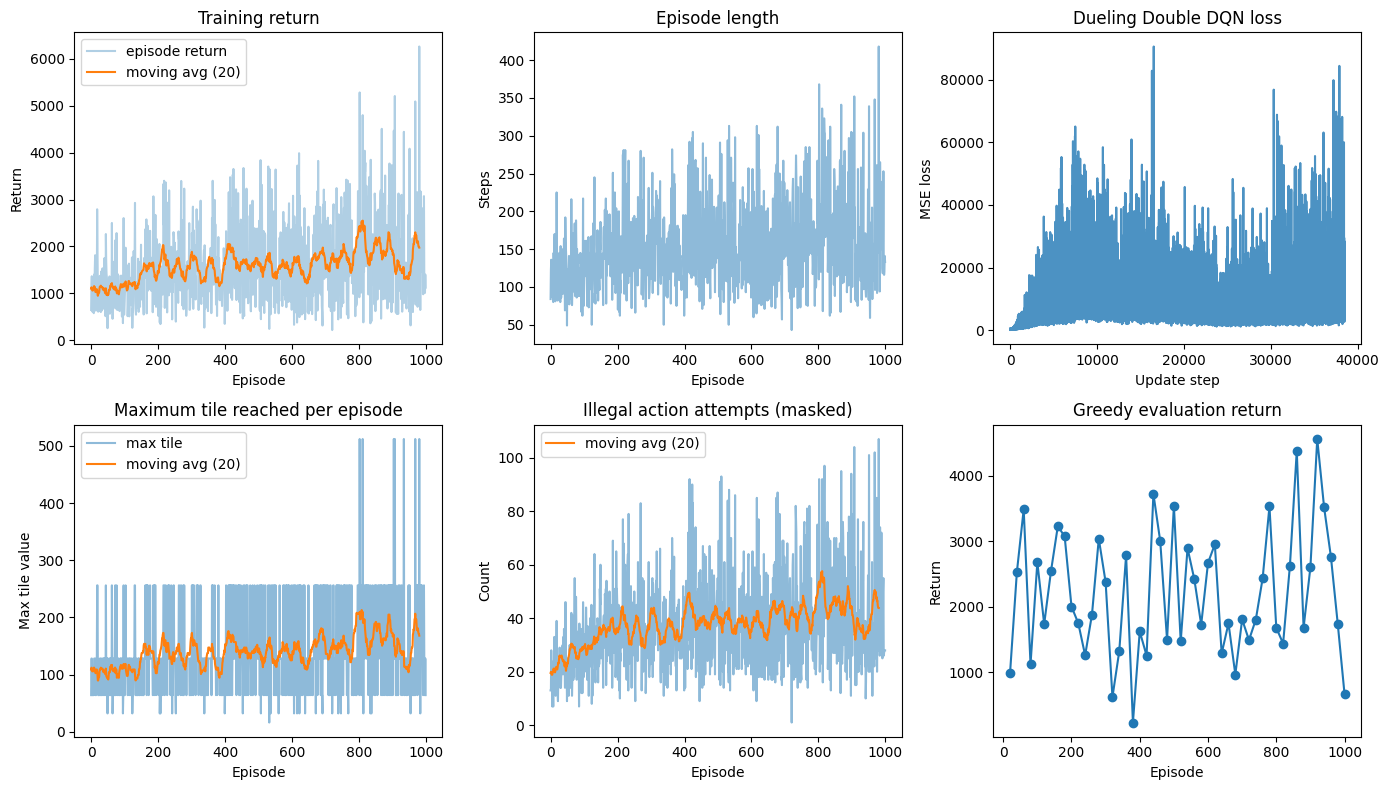

In [9]:
def moving_average(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w) / w, mode="valid")


plt.figure(figsize=(14, 8))

# Original metrics
plt.subplot(2, 3, 1)
plt.plot(episode_returns, alpha=0.35, label="episode return")
ma = moving_average(episode_returns, 20)
plt.plot(range(len(ma)), ma, label="moving avg (20)")
plt.title("Training return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(episode_lengths, alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(2, 3, 3)
plt.plot(loss_history, alpha=0.8)
plt.title("Dueling Double DQN loss")
plt.xlabel("Update step")
plt.ylabel("MSE loss")

# New metrics
plt.subplot(2, 3, 4)
plt.plot(max_tiles_per_episode, alpha=0.5, label="max tile")
ma_tiles = moving_average(max_tiles_per_episode, 20)
plt.plot(range(len(ma_tiles)), ma_tiles, label="moving avg (20)")
plt.title("Maximum tile reached per episode")
plt.xlabel("Episode")
plt.ylabel("Max tile value")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(illegal_action_attempts, alpha=0.5)
ma_illegal = moving_average(illegal_action_attempts, 20)
plt.plot(range(len(ma_illegal)), ma_illegal, label="moving avg (20)")
plt.title("Illegal action attempts (masked)")
plt.xlabel("Episode")
plt.ylabel("Count")
plt.legend()

plt.subplot(2, 3, 6)
if eval_returns:
    eval_eps, eval_vals = zip(*eval_returns)
    plt.plot(eval_eps, eval_vals, marker="o")
    plt.title("Greedy evaluation return")
    plt.xlabel("Episode")
    plt.ylabel("Return")

plt.tight_layout()
plt.show()

## 6. Greedy evaluation and checkpoint

The last cell runs a greedy rollout and saves the trained model.

In [10]:
import json

eval_env = OpenSpiel2048Env(seed=999)
obs = eval_env.reset(seed=999)
done = False
greedy_return = 0.0
rollout = []

while not done and len(rollout) < MAX_STEPS_PER_EPISODE:
    legal = eval_env.legal_actions()
    action = masked_greedy_action(
        q_net, obs, legal, num_actions, epsilon=0.0, device=DEVICE
    )
    next_obs, reward, done, info = eval_env.step(action)
    rollout.append(
        {
            "action": action,
            "reward": reward,
            "legal_actions": legal,
            "board": info["board"],
            "state_text": info["state_text"],
        }
    )
    obs = next_obs
    greedy_return += reward

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", len(rollout))
print()
eval_env.render()

output_dir = "./output/dueling-double-dqn"
os.makedirs(output_dir, exist_ok=True)

num_eval_seeds = 10
multi_seed_returns = []
multi_seed_lengths = []
multi_seed_max_tiles = []

eval_rollout_seed_ids = []
eval_rollout_episode_ids = []
eval_rollout_step_ids = []
eval_rollout_states = []
eval_rollout_next_states = []
eval_rollout_actions = []
eval_rollout_rewards = []
eval_rollout_dones = []
eval_rollout_legal_masks = []
eval_rollout_episode_returns = []
eval_rollout_episode_lengths = []

for seed_idx in range(num_eval_seeds):
    eval_seed = 5000 + seed_idx
    eval_env_ms = OpenSpiel2048Env(seed=eval_seed)
    obs_ms = eval_env_ms.reset(seed=eval_seed)
    done_ms = False
    ret_ms = 0.0
    steps_ms = 0
    max_tile_ms = 0

    eval_rollout_seed_ids.append(eval_seed)

    while not done_ms and steps_ms < MAX_STEPS_PER_EPISODE:
        if obs_ms is not None and len(obs_ms) > 0:
            max_tile_ms = max(max_tile_ms, int(np.max(obs_ms)))

        legal = eval_env_ms.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)
        action = masked_greedy_action(
            q_net, obs_ms, legal, num_actions, epsilon=0.0, device=DEVICE
        )
        next_obs_ms, reward, done_ms, info_ms = eval_env_ms.step(action)

        eval_rollout_episode_ids.append(seed_idx)
        eval_rollout_step_ids.append(steps_ms)
        eval_rollout_states.append(np.asarray(obs_ms, dtype=np.float32))
        eval_rollout_next_states.append(np.asarray(next_obs_ms, dtype=np.float32))
        eval_rollout_actions.append(int(action))
        eval_rollout_rewards.append(float(reward))
        eval_rollout_dones.append(bool(done_ms))
        eval_rollout_legal_masks.append(legal_mask.astype(np.bool_))

        obs_ms = next_obs_ms
        ret_ms += reward
        steps_ms += 1

    multi_seed_returns.append(ret_ms)
    multi_seed_lengths.append(steps_ms)
    multi_seed_max_tiles.append(max_tile_ms)
    eval_rollout_episode_returns.append(ret_ms)
    eval_rollout_episode_lengths.append(steps_ms)

avg_return = np.mean(multi_seed_returns)
std_return = np.std(multi_seed_returns)
avg_length = np.mean(multi_seed_lengths)
avg_max_tile = np.mean(multi_seed_max_tiles)

np.savez_compressed(
    os.path.join(output_dir, "eval_rollout.npz"),
    seed_ids=np.asarray(eval_rollout_seed_ids, dtype=np.int64),
    episode_ids=np.asarray(eval_rollout_episode_ids, dtype=np.int64),
    step_ids=np.asarray(eval_rollout_step_ids, dtype=np.int64),
    states=np.stack(eval_rollout_states).astype(np.float32),
    next_states=np.stack(eval_rollout_next_states).astype(np.float32),
    actions=np.asarray(eval_rollout_actions, dtype=np.int64),
    rewards=np.asarray(eval_rollout_rewards, dtype=np.float32),
    dones=np.asarray(eval_rollout_dones, dtype=np.bool_),
    legal_masks=np.stack(eval_rollout_legal_masks).astype(np.bool_),
    episode_returns=np.asarray(eval_rollout_episode_returns, dtype=np.float32),
    episode_lengths=np.asarray(eval_rollout_episode_lengths, dtype=np.int64),
    max_tiles=np.asarray(multi_seed_max_tiles, dtype=np.int64),
    num_actions=np.int64(num_actions),
    obs_dim=np.int64(obs_dim),
)

eval_meta = {
    "schema_version": 1,
    "game": "2048",
    "library": "OpenSpiel",
    "source_notebook": "Dueling Double DQN",
    "checkpoint_file": "dqn.pt",
    "rollout_file": "eval_rollout.npz",
    "num_eval_seeds": num_eval_seeds,
    "seed_ids": eval_rollout_seed_ids,
    "obs_dim": int(obs_dim),
    "num_actions": int(num_actions),
    "action_order": "OpenSpiel action indices 0..num_actions-1",
    "state_encoding": "flat observation tensor from app.helpers.extract_obs",
    "state_storage": "pre-action and post-action observations in eval_rollout.npz",
    "episode_boundaries": "episode_ids and step_ids define episode grouping",
    "outputs_dir": output_dir,
}

with open(os.path.join(output_dir, "eval_meta.json"), "w", encoding="utf-8") as meta_file:
    json.dump(eval_meta, meta_file, indent=2)

print(f"Saved evaluation rollout archive to: {os.path.join(output_dir, 'eval_rollout.npz')}")
print(f"Saved evaluation metadata to: {os.path.join(output_dir, 'eval_meta.json')}")
print(f"Saved {len(eval_rollout_actions)} transitions across {num_eval_seeds} evaluation episodes.")

print(f"\nResults over {num_eval_seeds} seeds:")
print(f"  Average return:        {avg_return:.1f} ± {std_return:.1f}")
print(f"  Average episode length: {avg_length:.1f}")
print(f"  Average max tile:       {avg_max_tile:.1f}")
print(f"\nPer-seed returns: {[f'{r:.1f}' for r in multi_seed_returns]}")
print(f"Per-seed max tiles: {[f'{t:.0f}' for t in multi_seed_max_tiles]}")

checkpoint_path = os.path.join(output_dir, "dqn.pt")
torch.save(
    {
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "obs_dim": obs_dim,
        "num_actions": num_actions,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "loss_history": loss_history,
    },
    checkpoint_path,
)
print("Saved checkpoint to:", checkpoint_path)

Greedy evaluation return: 3224.0
Rollout length: 270

    4   16   64    2
    2  128   32    4
    8  256   16    8
   32   16    4    2

Saved evaluation rollout archive to: ./output/dueling-double-dqn/eval_rollout.npz
Saved evaluation metadata to: ./output/dueling-double-dqn/eval_meta.json
Saved 2236 transitions across 10 evaluation episodes.

Results over 10 seeds:
  Average return:        2511.2 ± 1152.8
  Average episode length: 223.6
  Average max tile:       192.0

Per-seed returns: ['1132.0', '1464.0', '3968.0', '3680.0', '3568.0', '2344.0', '3248.0', '3420.0', '1668.0', '620.0']
Per-seed max tiles: ['64', '128', '256', '256', '256', '256', '256', '256', '128', '64']
Saved checkpoint to: ./output/dueling-double-dqn/dqn.pt
